In [1]:
from pynq import Overlay, allocate
import numpy as np
import time
import os
import re
from PIL import Image

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load the CORRECT bitstream
overlay = Overlay("cnn_2layer_quant.bit")

# Initialize DMA and IP
dma = overlay.axi_dma_0
cnn_ip = overlay.cnn_accel_0

# Start the IP (Write 0x81 to Control Register)
cnn_ip.write(0x00, 0x81)

print("Bitstream loaded. Accelerator STARTED.")

Bitstream loaded. Accelerator STARTED.


In [3]:
def load_weights(filename):
    print(f"Parsing weights from {filename}...")
    weights = {}
    
    if not os.path.exists(filename):
        print(f"ERROR: {filename} not found.")
        return None

    with open(filename, "r") as f:
        content = f.read()

    # Regex to find arrays
    pattern = r"const\s+(?:signed\s+char|int)\s+(\w+)\[\d*\]\s*=\s*\{([^}]+)\};"
    matches = re.findall(pattern, content, re.DOTALL)
    
    for name, data_str in matches:
        clean_str = re.sub(r'//.*', '', data_str)
        values = [int(x.strip()) for x in clean_str.split(',') if x.strip()]
        weights[name] = np.array(values, dtype=np.int32)
        print(f"  Loaded {name}: {len(values)} elements")

    # Reshape for CNN logic
    try:
        weights['conv_1_w'] = weights['conv_1_w'].reshape(3, 3, 1, 8)
        weights['conv_2_w'] = weights['conv_2_w'].reshape(3, 3, 8, 16)
        weights['output_dense_w'] = weights['output_dense_w'].reshape(400, 10)
        print("Weights loaded and reshaped successfully.")
        return weights
    except Exception as e:
        print(f"Error reshaping: {e}")
        return None

SW_WEIGHTS = load_weights("weights_quant.h")

Parsing weights from weights_quant.h...
  Loaded conv_1_w: 72 elements
  Loaded conv_1_b: 8 elements
  Loaded conv_2_w: 1152 elements
  Loaded conv_2_b: 16 elements
  Loaded output_dense_w: 4000 elements
  Loaded output_dense_b: 10 elements
Weights loaded and reshaped successfully.


In [4]:
# Scaling Factors from your header file
L1_SCALE = 0.00132719
L2_SCALE = 0.00209012

def sw_manual_inference(img_flat, w):
    # Input 0-255
    x = img_flat.reshape(28, 28, 1).astype(np.int32)
    
    # --- LAYER 1 ---
    l1_out = np.zeros((26, 26, 8), dtype=np.int32)
    k1, b1 = w['conv_1_w'], w['conv_1_b']
    
    for r in range(26):
        for c in range(26):
            patch = x[r:r+3, c:c+3, :]
            for f in range(8):
                conv_sum = np.sum(patch * k1[:,:,:,f]) + b1[f]
                if conv_sum < 0: conv_sum = 0 # ReLU
                
                # Apply Scaling (Matches HLS)
                scaled = conv_sum * L1_SCALE
                if scaled > 127: scaled = 127
                l1_out[r, c, f] = int(scaled)

    # MaxPool 1
    l1_pool = np.zeros((13, 13, 8), dtype=np.int32)
    for r in range(13):
        for c in range(13):
            window = l1_out[r*2:r*2+2, c*2:c*2+2, :]
            l1_pool[r, c, :] = np.max(window, axis=(0,1))
            
    # --- LAYER 2 ---
    l2_out = np.zeros((11, 11, 16), dtype=np.int32)
    k2, b2 = w['conv_2_w'], w['conv_2_b']
    
    for r in range(11):
        for c in range(11):
            patch = l1_pool[r:r+3, c:c+3, :]
            for f in range(16):
                conv_sum = np.sum(patch * k2[:,:,:,f]) + b2[f]
                if conv_sum < 0: conv_sum = 0
                
                # Apply Scaling
                scaled = conv_sum * L2_SCALE
                if scaled > 127: scaled = 127
                l2_out[r, c, f] = int(scaled)
                
    # MaxPool 2
    l2_pool = np.zeros((5, 5, 16), dtype=np.int32)
    for r in range(5):
        for c in range(5):
             window = l2_out[r*2:r*2+2, c*2:c*2+2, :]
             l2_pool[r, c, :] = np.max(window, axis=(0,1))
             
    # --- DENSE ---
    flat = l2_pool.flatten()
    dense_out = np.dot(flat, w['output_dense_w']) + w['output_dense_b']
    
    return np.argmax(dense_out)

print("Software model defined.")

Software model defined.


In [8]:
# Cell 5: Single Image Test (Fixed Signed Output)
img_folder = "mnist_test_images"
img_files = sorted([f for f in os.listdir(img_folder) if f.endswith(".png")])
test_file = img_files[0] # Pick the first image

print(f"Testing: {test_file}")

# 1. Prepare Input (0-255 Raw)
img = Image.open(f"{img_folder}/{test_file}").convert('L').resize((28, 28))
img_flat = np.array(img).flatten().astype(np.uint32)

# 2. Allocations
input_buffer = allocate(shape=(784,), dtype=np.uint32)
output_buffer = allocate(shape=(10,), dtype=np.uint32)

# Copy Input
np.copyto(input_buffer, img_flat)
np.copyto(output_buffer, np.zeros(10, dtype=np.uint32)) # Clear output

# 3. Hardware Run
start_t = time.time()
dma.recvchannel.transfer(output_buffer)
dma.sendchannel.transfer(input_buffer)
dma.sendchannel.wait()
dma.recvchannel.wait()
end_t = time.time()

# 4. Software Run (Manual Python Model)
sw_pred = sw_manual_inference(img_flat, SW_WEIGHTS)

# 5. Process Results (THE FIX)
# The FPGA sends raw bits. We must view them as SIGNED integers (int32)
# This converts "4294..." back into negative numbers like "-36727"
hw_scores = output_buffer.view(np.int32)
hw_pred = np.argmax(hw_scores)

# 6. Print Results
print("-" * 40)
print(f"FPGA Scores (Signed): {hw_scores}")
print(f"FPGA Prediction:      {hw_pred}")
print(f"CPU Prediction:       {sw_pred}")
print(f"True Label:           {test_file.split('_')[1]}")
print("-" * 40)
print(f"Latency: {(end_t - start_t)*1000:.3f} ms")

if hw_pred == sw_pred:
    print("SUCCESS: Match!")
else:
    print("MISMATCH: Check weights or scaling again.")

del input_buffer, output_buffer

Testing: digit_0_0.png
----------------------------------------
FPGA Scores (Signed): [ 29641 -36727  -1806 -25216 -15487 -15667   4801  -9599 -24491 -11161]
FPGA Prediction:      0
CPU Prediction:       0
True Label:           0
----------------------------------------
Latency: 3.706 ms
SUCCESS: Match!


In [7]:
# Cell 6: Final Benchmark (Corrected for Signed Outputs)
print(f"Starting Benchmark on {len(img_files)} images...")

hw_correct = 0
sw_correct = 0
total_hw_time = 0
total_sw_time = 0

# Allocation
in_buf = allocate(shape=(784,), dtype=np.uint32)
out_buf = allocate(shape=(10,), dtype=np.uint32)

for i, filename in enumerate(img_files):
    if i % 10 == 0: print(f"Processing {i}...")
    
    try: true_label = int(filename.split('_')[1])
    except: continue
        
    img = Image.open(f"{img_folder}/{filename}").convert('L').resize((28, 28))
    img_flat = np.array(img).flatten().astype(np.uint32)
    
    # --- HW ---
    np.copyto(in_buf, img_flat)
    t1 = time.time()
    dma.recvchannel.transfer(out_buf)
    dma.sendchannel.transfer(in_buf)
    dma.sendchannel.wait()
    dma.recvchannel.wait()
    t2 = time.time()
    
    # --- CRITICAL FIX: Interpret bits as SIGNED integers ---
    # The FPGA sends raw bits. We must tell Python they are signed (int32).
    hw_scores = out_buf.view(np.int32)
    
    if np.argmax(hw_scores) == true_label: hw_correct += 1
    total_hw_time += (t2 - t1) * 1000
    
    # --- SW ---
    t1 = time.time()
    sw_pred = sw_manual_inference(img_flat, SW_WEIGHTS)
    t2 = time.time()
    
    if sw_pred == true_label: sw_correct += 1
    total_sw_time += (t2 - t1) * 1000

del in_buf, out_buf

# Report
count = len(img_files)
print("\n" + "="*50)
print(f"FINAL REPORT (Count: {count})")
print("="*50)
print(f"FPGA Accuracy:    {(hw_correct/count)*100:.2f}%")
print(f"CPU Accuracy:     {(sw_correct/count)*100:.2f}%")
print("-" * 50)
print(f"Avg FPGA Latency: {total_hw_time/count:.4f} ms")
print(f"Avg CPU Latency:  {total_sw_time/count:.4f} ms")
print(f"Speedup Factor:   {(total_sw_time/total_hw_time):.2f}x")
print("="*50)

Starting Benchmark on 100 images...
Processing 0...
Processing 10...
Processing 20...
Processing 30...
Processing 40...
Processing 50...
Processing 60...
Processing 70...
Processing 80...
Processing 90...

FINAL REPORT (Count: 100)
FPGA Accuracy:    97.00%
CPU Accuracy:     97.00%
--------------------------------------------------
Avg FPGA Latency: 1.1077 ms
Avg CPU Latency:  1496.5344 ms
Speedup Factor:   1351.01x


In [10]:
# Cell 7: TFLite Inference on ARM (Optimized Software Benchmark)
import tflite_runtime.interpreter as tflite

# 1. Load the TFLite model
interpreter = tflite.Interpreter(model_path="mnist_cnn_quant.tflite")
interpreter.allocate_tensors()

# 2. Get input and output details
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]
scale, zero_point = input_details['quantization']

print(f"Starting TFLite Benchmark on {len(img_files)} images...")

tfl_correct = 0
total_tfl_time = 0

for i, filename in enumerate(img_files):
    # Load Label & Image
    try: true_label = int(filename.split('_')[1])
    except: continue
        
    img = Image.open(f"{img_folder}/{filename}").convert('L').resize((28, 28))
    img_flat = np.array(img).flatten()
    
    # Preprocess for TFLite (Normalized Float -> INT8)
    img_norm = img_flat.astype(np.float32) / 255.0
    img_tfl = (img_norm / scale + zero_point).astype(np.int8).reshape(1, 28, 28, 1)

    # --- TFLITE RUN ---
    t_start = time.time()
    interpreter.set_tensor(input_details['index'], img_tfl)
    interpreter.invoke()
    tfl_out = interpreter.get_tensor(output_details['index'])
    t_end = time.time()
    
    total_tfl_time += (t_end - t_start) * 1000
    if np.argmax(tfl_out) == true_label:
        tfl_correct += 1

# --- TFLITE REPORT ---
count = len(img_files)
avg_tfl = total_tfl_time / count
print("\n" + "="*50)
print(f"TFLITE ARM REPORT (Count: {count})")
print("="*50)
print(f"TFLite Accuracy:   {(tfl_correct/count)*100:.2f}%")
print(f"Avg TFLite Latency: {avg_tfl:.4f} ms")
print("-" * 50)
print(f"FPGA vs TFLite Speedup: {avg_tfl / (total_hw_time/count):.2f}x")
print("="*50)

Starting TFLite Benchmark on 100 images...

TFLITE ARM REPORT (Count: 100)
TFLite Accuracy:   99.00%
Avg TFLite Latency: 1.1039 ms
--------------------------------------------------
FPGA vs TFLite Speedup: 1.00x


Searching for misclassified images...


/usr/local/share/pynq-venv/lib/python3.10/site-packages/numpy/core/getlimits.py:500: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/usr/local/share/pynq-venv/lib/python3.10/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)


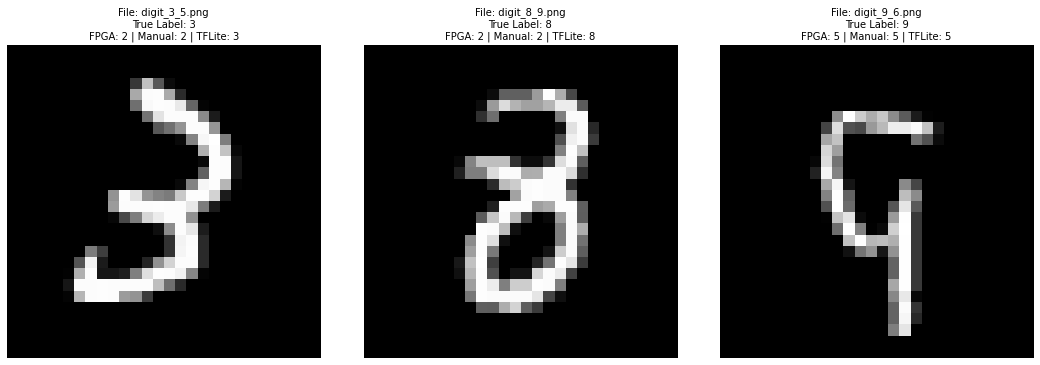

In [11]:
# Cell 8: Visualize Misclassifications
import matplotlib.pyplot as plt

# Setup
errors = []
in_buf = allocate(shape=(784,), dtype=np.uint32)
out_buf = allocate(shape=(10,), dtype=np.uint32)

print("Searching for misclassified images...")

for filename in img_files:
    # 1. Get True Label
    true_label = int(filename.split('_')[1])
    
    # 2. Prepare Data
    img_path = os.path.join(img_folder, filename)
    img_pil = Image.open(img_path).convert('L').resize((28, 28))
    img_flat = np.array(img_pil).flatten()
    
    # --- FPGA Prediction ---
    np.copyto(in_buf, img_flat.astype(np.uint32))
    dma.recvchannel.transfer(out_buf)
    dma.sendchannel.transfer(in_buf)
    dma.sendchannel.wait()
    dma.recvchannel.wait()
    fpga_pred = np.argmax(out_buf.view(np.int32))
    
    # --- Manual CPU Prediction ---
    manual_pred = sw_manual_inference(img_flat, SW_WEIGHTS)
    
    # --- TFLite Prediction ---
    img_norm = img_flat.astype(np.float32) / 255.0
    img_tfl = (img_norm / scale + zero_point).astype(np.int8).reshape(1, 28, 28, 1)
    interpreter.set_tensor(input_details['index'], img_tfl)
    interpreter.invoke()
    tflite_pred = np.argmax(interpreter.get_tensor(output_details['index']))
    
    # 3. If ANY model is wrong, save for plotting
    if (fpga_pred != true_label) or (manual_pred != true_label) or (tflite_pred != true_label):
        errors.append({
            'name': filename,
            'image': img_pil,
            'true': true_label,
            'fpga': fpga_pred,
            'manual': manual_pred,
            'tflite': tflite_pred
        })

# --- Plotting ---
if len(errors) == 0:
    print("No errors found!")
else:
    cols = 3
    rows = (len(errors) // cols) + (1 if len(errors) % cols != 0 else 0)
    plt.figure(figsize=(15, rows * 5))
    
    for i, err in enumerate(errors):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(err['image'], cmap='gray')
        
        # Color the labels: Red if wrong, Green if correct
        c_fpga = 'green' if err['fpga'] == err['true'] else 'red'
        c_manual = 'green' if err['manual'] == err['true'] else 'red'
        c_tflite = 'green' if err['tflite'] == err['true'] else 'red'
        
        title = f"File: {err['name']}\nTrue Label: {err['true']}\n"
        title += f"FPGA: {err['fpga']} | Manual: {err['manual']} | TFLite: {err['tflite']}"
        
        plt.title(title, fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

del in_buf, out_buf

In [50]:
from IPython.display import HTML, display
import json

canvas_html = """
<div style="border: 2px solid #555; padding: 15px; background: #1e1e1e; width: 310px;">
    <canvas id="fpga_canvas" width="280" height="280" style="background: black; cursor: crosshair;"></canvas>
    <br>
    <button onclick="clearCanvas()" style="margin:5px; padding:10px; background:#f44336; color:white;">Clear</button>
    <button onclick="sendToKernel()" style="margin:5px; padding:10px; background:#4CAF50; color:white;">Send to FPGA</button>
    <div id="status" style="color: white; font-family: monospace; margin-top: 10px;">Status: Waiting for Drawing...</div>
</div>

<script>
    var canvas = document.getElementById('fpga_canvas');
    var ctx = canvas.getContext('2d');
    var drawing = false;
    ctx.strokeStyle = "white"; ctx.lineWidth = 20; ctx.lineCap = "round";

    canvas.onmousedown = () => { drawing = true; };
    canvas.onmouseup = () => { drawing = false; ctx.beginPath(); };
    canvas.onmousemove = (e) => {
        if (!drawing) return;
        var rect = canvas.getBoundingClientRect();
        ctx.lineTo(e.clientX - rect.left, e.clientY - rect.top);
        ctx.stroke();
    };

    function clearCanvas() {
        ctx.fillStyle = "black"; ctx.fillRect(0, 0, 280, 280);
        document.getElementById('status').innerText = "Status: Cleared";
    }

    function sendToKernel() {
        var tempCanvas = document.createElement('canvas');
        tempCanvas.width = 28; tempCanvas.height = 28;
        tempCanvas.getContext('2d').drawImage(canvas, 0, 0, 28, 28);
        var data = tempCanvas.getContext('2d').getImageData(0, 0, 28, 28).data;
        var pixels = [];
        for (var i = 0; i < data.length; i += 4) pixels.push(data[i]);
        
        // This pushes the data into a global variable 'shared_buffer'
        IPython.notebook.kernel.execute("shared_buffer = " + JSON.stringify(pixels));
        document.getElementById('status').innerText = "Status: Sent! Check Cell Below.";
    }
</script>
"""
display(HTML(canvas_html))
shared_buffer = None # Initialize the buffer

In [53]:
import time
import numpy as np

print("FPGA Listener ACTIVE. Waiting for data from canvas...")

try:
    while True:
        if shared_buffer is not None:
            # 1. Grab data and immediately reset buffer to prevent double-runs
            local_pixels = list(shared_buffer)
            shared_buffer = None 
            
            # 2. Process with FPGA
            img_flat = np.array(local_pixels).astype(np.uint32)
            in_buf = allocate(shape=(784,), dtype=np.uint32)
            out_buf = allocate(shape=(10,), dtype=np.uint32)
            
            # Reset IP
            cnn_ip.write(0x00, 0x81) 
            
            # Transfer
            np.copyto(in_buf, img_flat)
            dma.recvchannel.transfer(out_buf)
            dma.sendchannel.transfer(in_buf)
            dma.sendchannel.wait()
            dma.recvchannel.wait()
            
            # 3. Output Results
            scores = out_buf.view(np.int32)
            prediction = np.argmax(scores)
            
            print(f"\n--- FPGA INFERENCE ---")
            print(f"Prediction: {prediction}")
            print(f"Scores: {scores}")
            print(f"Time: {time.ctime()}")
            
            # Cleanup
            del in_buf, out_buf
            
        time.sleep(0.1) # Check every 100ms
except KeyboardInterrupt:
    print("\nListener Stopped.")

FPGA Listener ACTIVE. Waiting for data from canvas...

--- FPGA INFERENCE ---
Prediction: 3
Scores: [-33971 -18063    722  30616 -37895 -12832 -41275 -38940 -27300 -49838]
Time: Sat Jan 24 19:02:27 2026

Listener Stopped.
